In [13]:
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.backends.cudnn as cudnn  # noqa: PLR0402
import torch.nn as nn  # noqa: PLR0402
import torch.optim as optim  # noqa: PLR0402
import torchvision
from torch.optim import lr_scheduler
from torch.utils.data import ConcatDataset, DataLoader, random_split
from torchvision import datasets, models, transforms

cudnn.benchmark = True
plt.ion()   # interactive mode
# PyTorch idiom for using GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Variables for training

In [21]:
SEED = 42
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 0)



## Transforms and the data loading & Splitting 

In [14]:
# Standard ImageNet normalization values
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(), # Simple data augmentation
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

In [19]:
# Download and load the datasets
train_dataset = datasets.OxfordIIITPet(root='./data', split='trainval', 
                                       target_types='category', download=True, 
                                       transform=data_transforms['train'])

test_dataset = datasets.OxfordIIITPet(root='./data', split='test', 
                                      target_types='category', download=True, 
                                      transform=data_transforms['test'])
full_dataset = ConcatDataset([
    datasets.OxfordIIITPet(root='./data', split='trainval', target_types='category',
                           download=True, transform=data_transforms['test']),
    datasets.OxfordIIITPet(root='./data', split='test', target_types='category',
                           download=True, transform=data_transforms['test']),
])

# Split 70 / 15 / 15
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset, [0.7, 0.15, 0.15],
    generator=torch.Generator().manual_seed(SEED)
)

class_names = full_dataset.datasets[0].classes
print(len(class_names),class_names)


37 ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [ ]:

dataloaders = {
    'train': DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=NUM_WORKERS, worker_init_fn=seed_worker, generator=g),
    'val':   DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    'test':  DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

import random

# Set worker count dynamically based on available CPU cores (capped for safety)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

# 2. Tie generator seed to global SEED
g = torch.Generator()
g.manual_seed(SEED)

# # 3. Apply to DataLoader
# dataloaders = {
#     'train': DataLoader(
#         train_dataset,
#         batch_size=BATCH_SIZE,
#         shuffle=True,
#         num_workers=NUM_WORKERS,
#         worker_init_fn=seed_worker,
#         generator=g,
#     ),
#     'val': DataLoader(
#         test_dataset,
#         batch_size=BATCH_SIZE,
#         shuffle=False,
#         num_workers=NUM_WORKERS,
#     )
# }

class_names = train_dataset.classes
print(f"Number of classes: {len(class_names)}") # Should be 37 for this dataset

AttributeError: 'Subset' object has no attribute 'classes'

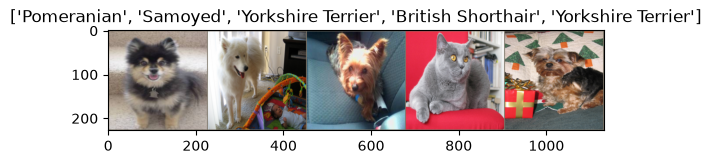

In [ ]:
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch and display
out = torchvision.utils.make_grid(inputs[:5]) # Just show 5 images
imshow(out, title=[class_names[x] for x in classes[:5]])

In [ ]:
import copy

from tqdm import tqdm


In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=5):
    since = time.time()

    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0    # Freeze the early layers (speeds up initial training)

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0
        
            for inputs, labels in tqdm(dataloaders[phase], desc=f"{phase} epoch {epoch+1}"):
                # Move data to the active device
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                # Zero the parameter gradients
                optimizer.zero_grad()
            
                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

            # statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        if phase == 'train':
            scheduler.step()
        phase_size = len(dataloaders[phase].dataset)
        epoch_loss = running_loss / phase_size
        epoch_acc = running_corrects.double() / phase_size

        print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        # deep copy the model
        if phase == 'val' and epoch_acc > best_acc:
            best_acc = epoch_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model

In [ ]:
# Load a pre-trained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False
    
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

# Define the Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
# Observe that all parameters are being optimized
num_epocs = 5
# Decay LR by a factor of 0.1 every 2 epochs
scheduler = lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

model_ft = train_model(model, criterion, optimizer, scheduler,num_epocs)

Epoch 1/5
----------


val epoch 1: 100%|██████████| 115/115 [02:54<00:00,  1.52s/it]


Train Loss: 0.0036 Acc: 0.0049
Training complete in 5m 57s
Best val Acc: 0.004906
Epoch 2/5
----------


train epoch 2:  43%|████▎     | 49/115 [01:16<01:43,  1.57s/it]


KeyboardInterrupt: 